# Interpretability: Inferring importances for GO and genes

`NetworkVI` is a Variational Autoencoder for the paired and mosaic integration of multimodal single-cell data. Each single-cell modality is learned in individual encoders; the latent spaces are then aligned for a joint representation. In this notebook we demonstrate how to use the inherent interpretability of `NetworkVI` to infer importances for GO terms and genes. We use a publically available CITE-seq dataset created by {cite}`Luecken2021`.

If you use `NetworkVI`, please consider citing:

Arnoldt, L., Upmeier zu Belzen, J., Herrmann, L., Nguyen, K., Theis, F.J., Wild, B. , Eils, R., "Biologically Guided Variational Inference for Interpretable Multimodal Single-Cell Integration and Mechanistic Discovery", bioRxiv, June 2025.

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install networkvi

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Liblinear failed to converge")

In [3]:
import numpy as np
import requests
import sys
sys.path.append("../../src")
import networkvi
from networkvi.model import NETWORKVI
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import sklearn
from sklearn.preprocessing import normalize
import seaborn as sns
import pandas as pd
from goatools.obo_parser import GODag
import shutil

In [4]:
%matplotlib inline

In [5]:
os.makedirs("../../resources/", exist_ok=True)

In [6]:
if not os.path.isfile(os.path.join("../../resources/", "go-basic.obo")):
    r = requests.get("http://purl.obolibrary.org/obo/go/go-basic.obo", allow_redirects=True)
    open(os.path.join("../../resources/", "go-basic.obo"), 'wb').write(r.content)

In [7]:
gene_csv_path = "../../gene_interactions.csv"
gene_csv_url = "https://zenodo.org/records/19376389/files/ENCFF173VDJ_K562_GRCh38_contact_domains_juicertools.csv?download=1"

if not os.path.isfile(gene_csv_path):
    print(f"Downloading {gene_csv_path} from Zenodo...")
    r = requests.get(gene_csv_url)
    r.raise_for_status()
    with open(gene_csv_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")

## Data loading

We provide a subsetted and preprocessed version of the CITE-seq and Multiome dataset for this tutorial. We filtered low qualty cells, lowly expressed features and performed subsampling to 5000 cells and feature subselection to 4000 highly variable genes and 20000 highly variable ATAC peaks. `NetworkVI` accepts raw counts data for all modalities. For details on the preprocessing please refer to the manuscript and the code in the [NetworkVI reproducibility repository](https://github.com/LArnoldt/networkvi_reproducibility). In the repository we also provide scripts for downloading and processing the datasets used in the manuscript. The original CITE-seq dataset contains 90261 bone marrow mononuclear cells inferred at 4 different sites with 13953 genes and 143 proteins.

In [8]:
rna_cite_path = "neurips2021_cite_bmmc_luecken2021.h5ad"

try:
    rna_cite = sc.read_h5ad(rna_cite_path)
except OSError:
    import gdown

    gdown.download("https://drive.google.com/uc?export=download&id=1A9o8wZgWS6udFMXJ-ybXre1dCcCdsKt5")
    rna_cite = sc.read_h5ad(rna_cite_path)

rna_cite

AnnData object with n_obs × n_vars = 5000 × 4000
    obs: 'cell_type', 'Site', 'DonorID', 'DonorSmoker', 'DonorBMI', 'DonorAge'
    var: 'gene_stable_id', 'modality'
    uns: 'protein_expression'
    obsm: 'protein_expression'

## Data setup

To perform query-to-reference mapping, we select the cells inferred at one of the four different sites as the query dataset. We train `NetworkVI` on the rest of the dataset.

In [9]:
adata = rna_cite
query = adata[adata.obs["Site"] == "site1"].copy()
adata = adata[adata.obs["Site"] != "site1"].copy()

We register the fields and setup the anndata with a convenience function as shown below. `NetworkVI` requires as `MultiVI` to register the modality as the `batch_key`. Further batch information can be registered as `categorical_covariate_keys`.

In [10]:
NETWORKVI.setup_anndata(
    adata,
    batch_key="Site",
    protein_expression_obsm_key="protein_expression",
)

## Model setup and training

We demonstrate the setup and training of `NetworkVI`, which makes use of the Gene Ontology, as the encoder structure. Below we define a convenience function to get the latent representation and to visualize the latent space. `NetworkVI` requires as `MultiVI` the definition of the number of features per modality (`n_genes`, `n_proteins`, `n_regions`).

In [11]:
def get_plot_latent_representation(vae, adata):
    latent_representation = vae.get_latent_representation(modality="joint")
    adata.obsm["X_NetworkVI"] = latent_representation
    sc.pp.neighbors(adata, use_rep="X_NetworkVI")
    sc.tl.umap(adata, n_components=2)
    return adata

### NetworkVI

We select `NetworkVI` by setting `layers_encoder_type` to "go". The mapping of the features to the gene layer and the Gene Ontology requires ENSEMBL-IDs, which we provide in `ensembl_ids_genes` and `ensembl_ids_proteins`. We also provide the Gene Ontology and a gene-to-GO mapping file in `obo_file` and `map_ensembl_go`. Please don't use the provided mapping file in production since it's an artifically subsampled version of a real mapping file. Please refer to the scripts provided [here](https://github.com/Larnoldt/networkvi_reproducibility) or [here](https://geneontology.org/docs/go-annotation-file-gaf-format-2.1/) to download full mapping files.

In [12]:
vae = NETWORKVI(
    adata,
    n_genes=len(adata.var[adata.var["modality"] == "Gene Expression"]),
    n_proteins=adata.obsm["protein_expression"].shape[1],
    ensembl_ids_genes=np.array(adata.var[adata.var["modality"] == "Gene Expression"]["gene_stable_id"]),
    ensembl_ids_proteins=np.array(adata.uns["protein_expression"]["var"]["gene_stable_id"]),
    gene_layer_interaction_source="../../gene_interactions.csv",
    expression_gene_layer_type="interaction",
    protein_gene_layer_type="interaction",
    obo_file="../../resources/go-basic.obo",
    map_ensembl_go=["../../resources/ensembl2go.gaf"],
    layers_encoder_type="go",
    encode_covariates=True,
    deeply_inject_covariates=True,
    fully_paired=True,
    standard_gene_size=5,
    standard_go_size=2,
)

vae.train(max_epochs=10, adversarial_mixing=False, save_best=False)

Generated block structure with len 4000 (0.00025 blocks).


Generated block structure with len 7342 (0.000458875 blocks).


../../resources/go-basic.obo: fmt(1.2) rel(2025-03-16) 43,544 Terms; optional_attrs(relationship)


../../resources/go-basic.obo: fmt(1.2) rel(2025-03-16) 43,544 Terms; optional_attrs(relationship)


_biological_process_go-basic_ensembl2go.v2_processed.pkl
Using attention in GO model at level -1.
Generated block structure with len 4565 (0.07608333333333334 blocks).


...

Epoch 10/10:  90%|██████████████████████████████████████████████████▍     | 9/10 [02:08<00:13, 13.38s/it, v_num=1, train_loss_step=6.07e+3, train_loss_epoch=5.08e+3]

Epoch 10/10: 100%|███████████████████████████████████████████████████████| 10/10 [02:17<00:00, 12.27s/it, v_num=1, train_loss_step=6.07e+3, train_loss_epoch=5.08e+3]

Epoch 10/10: 100%|███████████████████████████████████████████████████████| 10/10 [02:17<00:00, 12.27s/it, v_num=1, train_loss_step=3.54e+3, train_loss_epoch=4.76e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|███████████████████████████████████████████████████████| 10/10 [02:17<00:00, 13.80s/it, v_num=1, train_loss_step=3.54e+3, train_loss_epoch=4.76e+3]

We can visualize the generated latent space:

In [13]:
adata = get_plot_latent_representation(vae, adata)

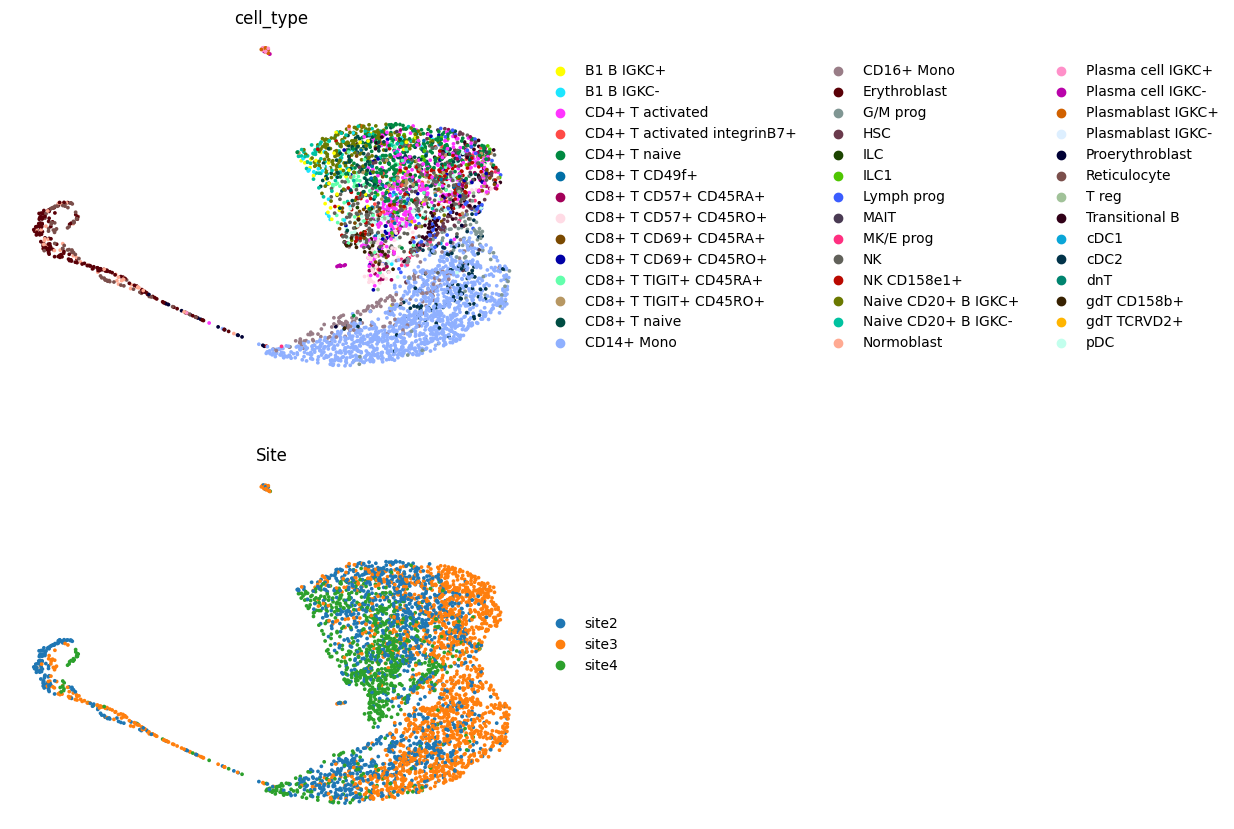

In [14]:
sc.pl.umap(adata, color=["cell_type", "Site"], frameon=False, ncols=1)

## Interpretability

By fitting a Logistic Regression on the activations of the nodes representing a GO term (`calc_go_terms`), a gene (`calc_genes`) or a gene_group (`calc_gene_groups`) we may infer the importance of this node for the performance of the neural network as described previously by {cite}`Ma2018`. Here, we demonstrate how to utilize the get_go_gene_importances and get_perturbation_go_gene_importances functions to infer the importances for the original dataset and for perturbed datasets in a sensitivity analysis. The importance is calculated in standard mode for each label against the rest. Using `labels_selection`, `labels_selection_groups`, `restrict_by_column_key_activations_mask`, `restrict_by_column_values_activations_mask` and `comparison` this behaviour may be modified. Please refer to the API documentation.

In [15]:
obodag = GODag(os.path.join("../../resources/", "go-basic.obo"))

../../resources/go-basic.obo: fmt(1.2) rel(2025-03-16) 43,544 Terms


In [16]:
_ = vae.get_go_gene_importances(labels_column="cell_type",
                                results_dir=f"tutorial/calc_go_terms",
                                shuffle_set_split=False,
                                batch_size=512,
                                calc_go_terms=True,
                                calc_genes=False,
                                calc_gene_groups=False,
                                save_fit=False)

**Important Note on Logistic Regression Convergence**

In this tutorial, we use a deliberately small, subsampled dataset (5,000 cells with 4,000 genes) to enable quick demonstration of `NetworkVI`'s interpretability features. This small dataset size has important implications for the downstream logistic regression analysis: When fitting logistic regression models to infer GO term and gene importances, you may encounter convergence warnings from scikit-learn's `Liblinear` solver. These warnings are **expected and not problematic** for this tutorial because:
1. **Limited separation between classes**: With only a small subset of cells per cell type and a limited number of genes mapped to each GO term (often just 2-12 genes), there may be insufficient signal for the logistic regression to find clear decision boundaries between cell types for many GO terms.
2. **Small sample sizes per GO term**: Many GO terms in this subsampled dataset are represented by very few genes, making it mathematically difficult for the classifier to converge to an optimal solution.
3. **Tutorial purposes**: The goal here is to demonstrate the *methodology* for interpretability analysis, not to draw biological conclusions from this small dataset.

**For production use**: When applying `NetworkVI` to full-scale datasets with tens of thousands of cells and comprehensive gene coverage, convergence issues are much less common as there is substantially more signal for the logistic regression models to learn from. The warnings have been suppressed in this notebook to improve readability, but the underlying convergence behavior remains the same.

THe function `get_go_gene_importances` saves the activations, GO importances and further information in a pandas pickle file. We then load these files and visualize the GO importance for a selection of GO terms for all available cell types.

In [17]:
go_importances = []
cell_types = []

In [18]:
for cell_type in sorted(np.unique(adata.obs["cell_type"])):
    cell_type_mod = cell_type.replace(" ", "_").replace("/", "_")
    try:
        go_importances.append(np.array(pd.read_pickle(f"./tutorial/calc_go_terms/protein_cell_type_vs_rest_{cell_type_mod}_res_unp_act_mask_False_flip_False_go_terms_evaluated_graph_csv.pkl")["predictors_label_valid_roc"]).astype("float"))
        cell_types.append(cell_type)
    except FileNotFoundError:
        continue

In [19]:
go_terms = list(pd.read_pickle(f"./tutorial/calc_go_terms/protein_cell_type_vs_rest_{cell_type_mod}_res_unp_act_mask_False_flip_False_go_terms_evaluated_graph_csv.pkl").index)
go_terms = [f"{obodag[go_term].name} ({go_term})" if go_term in obodag.keys() else go_term for go_term in go_terms]

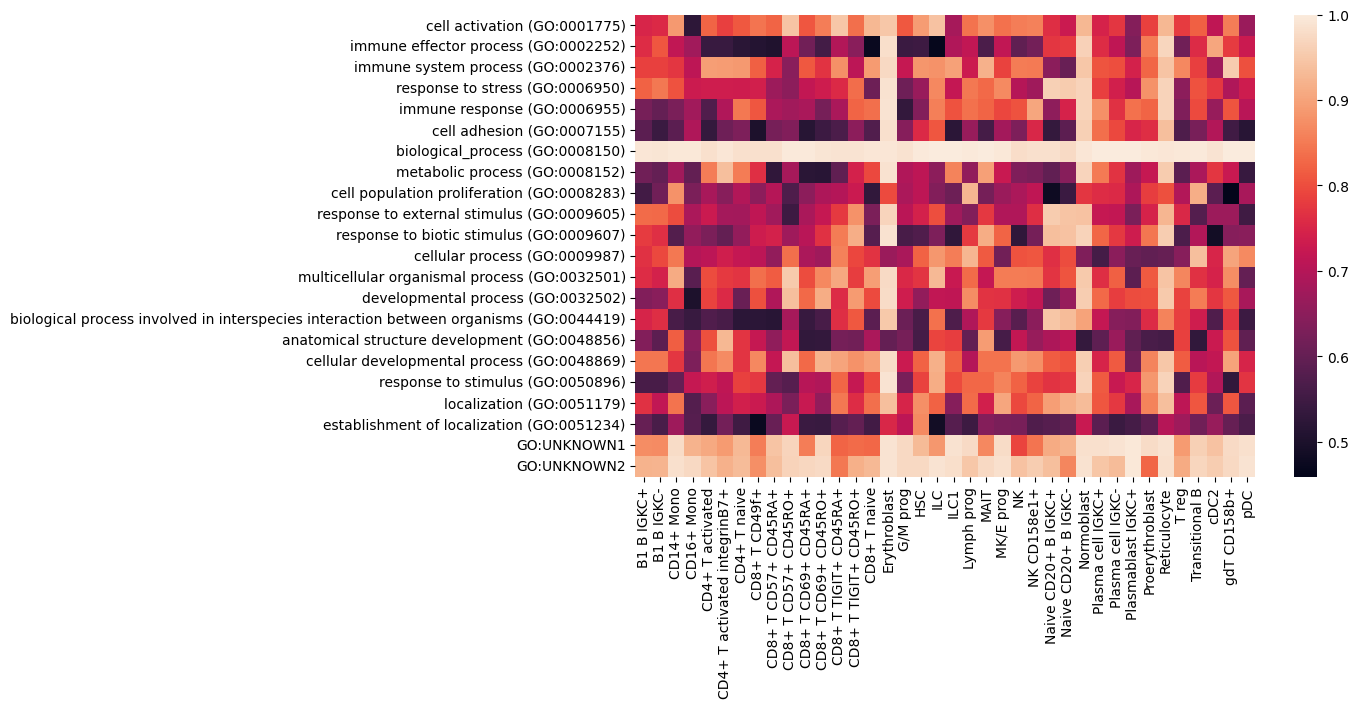

In [20]:
plt.figure(figsize=(10, 6))

sns.heatmap(np.array(go_importances).T, xticklabels=cell_types, yticklabels=go_terms)
plt.show()

In [21]:
shutil.rmtree("tutorial/calc_go_terms")

We also show how to perform a sensitivity analysis by perturbing features. Here we perturb CD86 (ENSG00000114013) by setting all values to zero. The function `get_perturbation_go_gene_importances` internally calls `get_go_gene_importances`, but additionally we need to provide the modality of the features in `modality_key` and the ENSEMBL-IDs in `gene_stable_id_key`.

In [22]:
perturbation_gene_stable_ids = ["ENSG00000114013"]

go_importances_perturbation = vae.get_perturbation_go_gene_importances(labels_column="cell_type",
                                               modality_key="modality",
                                               gene_stable_id_key="gene_stable_id",
                                               perturbation_gene_stable_ids=perturbation_gene_stable_ids,
                                               batch_size=512,
                                               shuffle_set_split=False,
                                               calc_go_terms=True,
                                               calc_genes=False,
                                               calc_gene_groups=False,)

We can visualize the change of the importance in comparison to the not-perturbed dataset accordingly:

In [23]:
go_importances_pert = []

for cell_type in cell_types:
    cell_type_mod = cell_type.replace(" ", "_").replace("/", "_")
    go_importances_pert.append(go_importances_perturbation["ENSG00000114013"]['protein']["protein"][cell_type_mod].astype("float"))

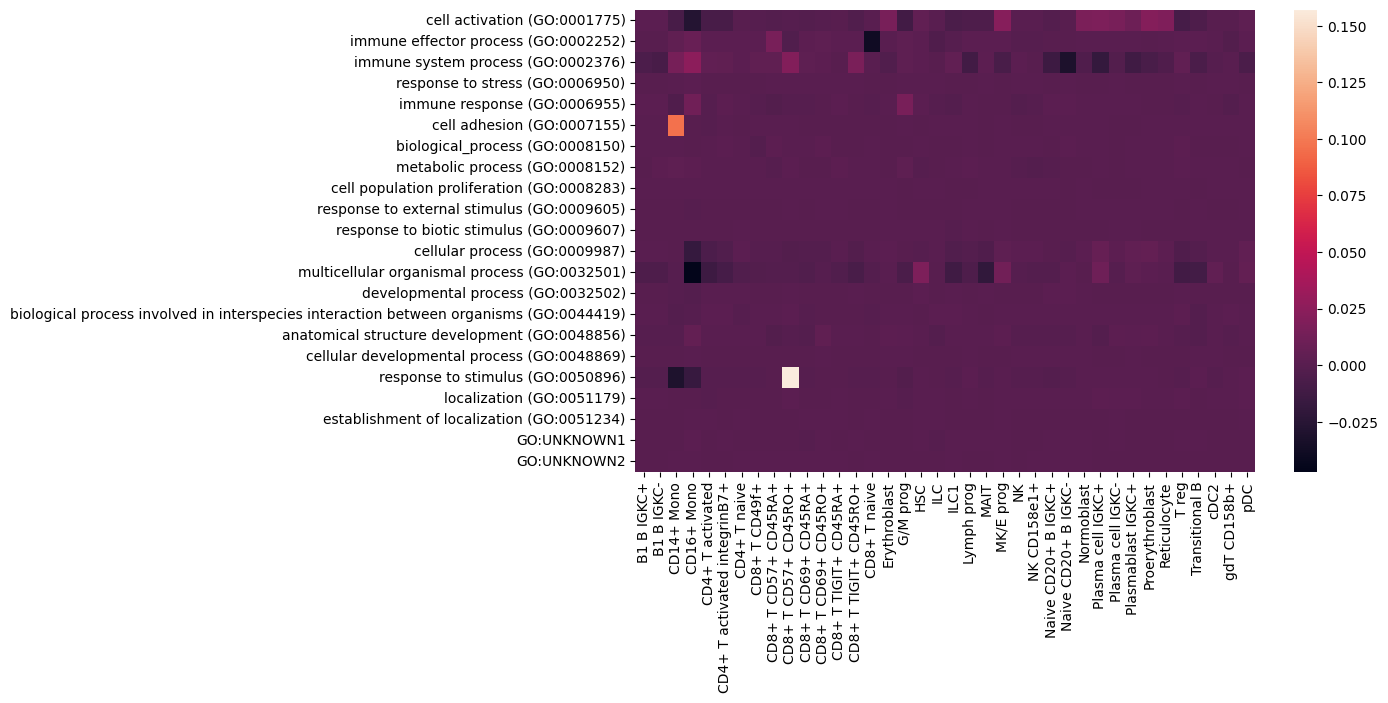

In [24]:
plt.figure(figsize=(10, 6))

sns.heatmap((np.array(go_importances) - np.array(go_importances_pert)).T, xticklabels=cell_types, yticklabels=go_terms)
plt.show()